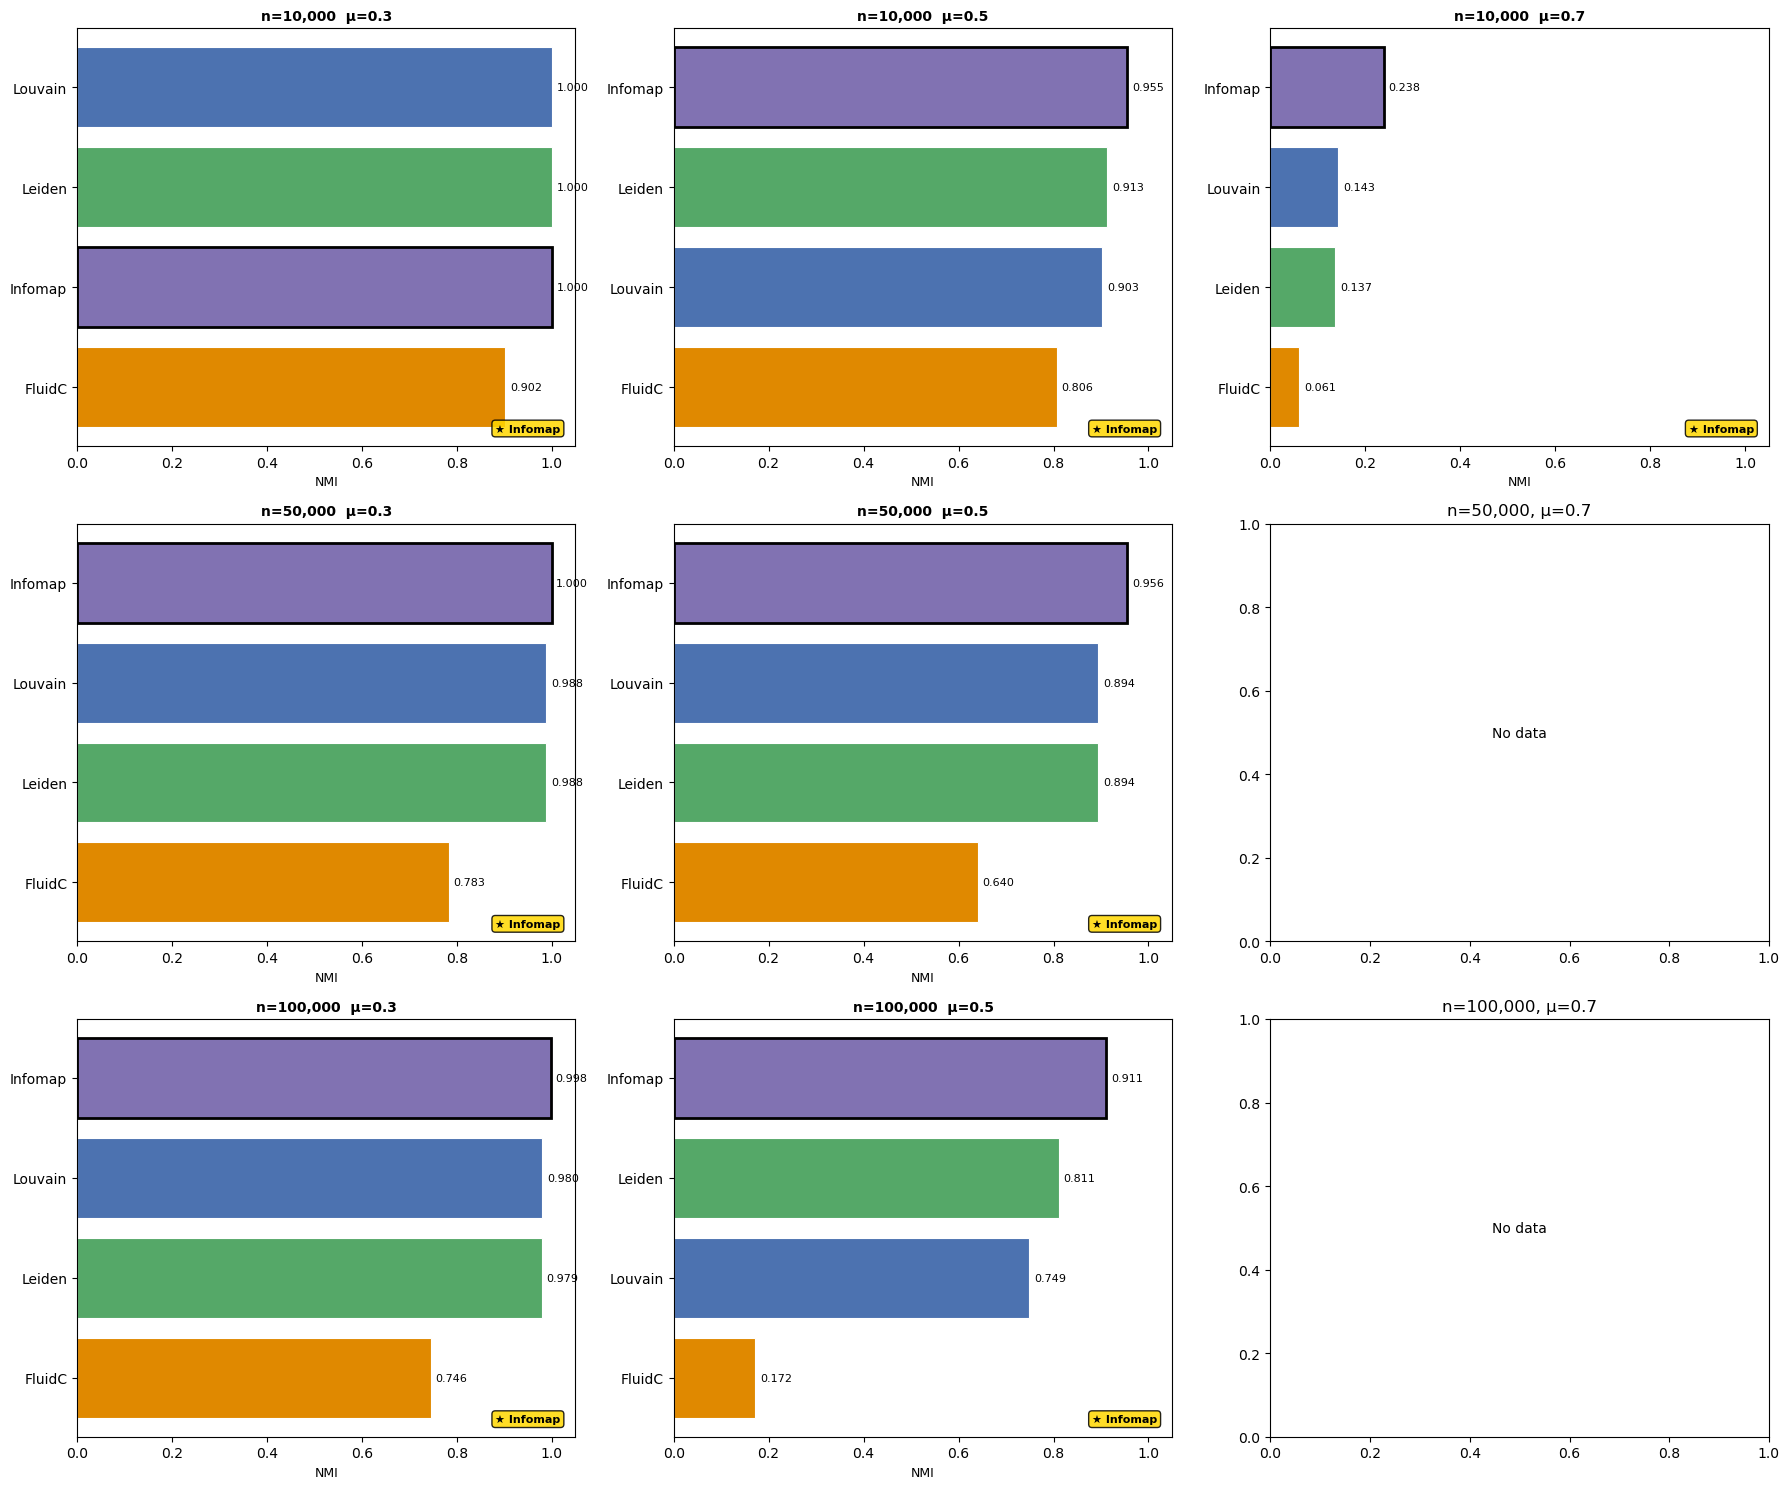

Saved: lfr_phase1_grid.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ALGO_COLORS = {
    # Classical
    "Louvain":      "#4C72B0", "Leiden":       "#55A868",
    "Walktrap":     "#C44E52", "Infomap":      "#8172B2",
    "LabelProp":    "#CCB974", "FastLPA":      "#64B5CD",
    "FluidC":       "#E08900", "MCL":          "#A9A9A9",
    "KernighanLin": "#D16B6B",
    # Deep learning
    "GCN":          "#1F77B4", "GAT":          "#FF7F0E",
    "VGAE":         "#2CA02C", "Autoencoder":  "#D62728",
}

def _bar_panel(ax, avg_df, title):
    """Horizontal bar chart for a single (n, μ) panel."""
    best   = avg_df.idxmax()
    colors = [ALGO_COLORS.get(a, "#888888") for a in avg_df.index]
    bars   = ax.barh(avg_df.index, avg_df.values, color=colors,
                     edgecolor="white", linewidth=0.8)
    for bar, alg in zip(bars, avg_df.index):
        if alg == best:
            bar.set_edgecolor("black"); bar.set_linewidth(2)
    for bar, val in zip(bars, avg_df.values):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("NMI", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.text(0.97, 0.03, f"★ {best}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="gold", alpha=0.85))

# Hard-coded data from your results
data = {
    (10000, 0.3): {"Louvain": 0.9997, "Leiden": 0.9997, "Infomap": 0.9997, "FluidC": 0.9016},
    (10000, 0.5): {"Louvain": 0.9027, "Leiden": 0.9131, "Infomap": 0.9554, "FluidC": 0.8065},
    (10000, 0.7): {"Louvain": 0.1430, "Leiden": 0.1369, "Infomap": 0.2383, "FluidC": 0.0610},
    (50000, 0.3): {"Louvain": 0.9883, "Leiden": 0.9880, "Infomap": 0.9996, "FluidC": 0.7832},
    (50000, 0.5): {"Louvain": 0.8944, "Leiden": 0.8944, "Infomap": 0.9558, "FluidC": 0.6403},
    (100000, 0.3): {"Louvain": 0.9804, "Leiden": 0.9794, "Infomap": 0.9975, "FluidC": 0.7456},
    (100000, 0.5): {"Louvain": 0.7491, "Leiden": 0.8110, "Infomap": 0.9111, "FluidC": 0.1715},
}

# Create DataFrame
rows = []
for (n, mu), alg_values in data.items():
    for algo, nmi in alg_values.items():
        rows.append({"n": n, "mu": mu, "Algorithm": algo, "NMI": nmi, "Status": "ok"})

df = pd.DataFrame(rows)

# Plot Phase 1 grid
def plot_phase1_grid(df: pd.DataFrame):
    sizes = sorted(df["n"].unique())
    mus   = sorted(df["mu"].unique())
    fig, axes = plt.subplots(len(sizes), len(mus),
                             figsize=(6*len(mus), 5*len(sizes)))
    if len(sizes) == 1: axes = axes[np.newaxis, :]
    if len(mus)   == 1: axes = axes[:, np.newaxis]

    for i, n in enumerate(sizes):
        for j, mu in enumerate(mus):
            ax  = axes[i, j]
            sub = df[(df["n"]==n) & (df["mu"]==mu) & (df["Status"]=="ok")]
            if sub.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center")
                ax.set_title(f"n={n:,}, μ={mu}")
                continue
            avg = sub.groupby("Algorithm")["NMI"].mean().sort_values()
            _bar_panel(ax, avg, f"n={n:,}  μ={mu}")


    plt.tight_layout()
    plt.savefig("lfr_phase1_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: lfr_phase1_grid.png")

# Generate the plot
plot_phase1_grid(df)